In [1]:
from shapely.geometry import shape

aoi_json = {
    "coordinates": [
          [
            [
              -3.9692772394496103,
              43.054120805076536
            ],
            [
              -3.9706989612007533,
              42.96584735243434
            ],
            [
              -3.8324788074527874,
              42.96560128564562
            ],
            [
              -3.8338117185189162,
              43.054093060968086
            ],
            [
              -3.8364752389759076,
              43.053893665689515
            ],
            [
              -3.8463997868913964,
              43.054856259232224
            ],
            [
              -3.9692772394496103,
              43.054120805076536
            ]
          ]
        ],
    "type": "Polygon"
}

aoi = shape(aoi_json)

In [3]:
import earthaccess
from pathlib import Path

# Enter username and password to login
earthaccess.login()

# Search for products within the AOI and Time frame
results = earthaccess.search_data(short_name='SWOT_L2_HR_PIXC_2.0', 
                                  temporal=('2023-11-01', '2023-11-30'), 
                                  bounding_box=aoi.bounds)

# Display the granules found
items = [item['meta']['native-id'] for item in results]
items

Enter your Earthdata Login username:  penaluques
Enter your Earthdata password:  ········


Granules found: 4


['SWOT_L2_HR_PIXC_006_141_230L_20231107T140001_20231107T140012_PGC0_01',
 'SWOT_L2_HR_PIXC_006_447_230R_20231118T122248_20231118T122259_PGC0_01',
 'SWOT_L2_HR_PIXC_006_447_231R_20231118T122258_20231118T122302_PGC0_01',
 'SWOT_L2_HR_PIXC_007_141_230L_20231128T104506_20231128T104517_PGC0_01']

In [4]:
# Download the first granule
earthaccess.download(results[:1], "/tmp/swot")

# create a path to it and assert it exists
file = Path('/tmp/swot/SWOT_L2_HR_PIXC_006_141_230L_20231107T140001_20231107T140012_PGC0_01.nc')
assert file.exists()


 Getting 1 granules, approx download size: 0.35 GB


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [59]:
import numpy as np
import xarray as xr
import geopandas as gpd

# Load the file to the XArray.Dataset
ds_pixc = xr.open_dataset(file, group='pixel_cloud', engine='h5netcdf')

# Load a GeoPandas DataFrame with the points and some variables
gdf = gpd.GeoDataFrame(
    data={
        'height': ds_pixc.height.values.astype('float32'),
        'classification': ds_pixc.classification.values.astype('uint8'),
        'coherent_power': ds_pixc.coherent_power.values.astype('float32'),
        'latitude': ds_pixc.latitude.values.astype('float32'),
        'longitude': ds_pixc.longitude.values.astype('float32'),
        'geolocation_qual': ds_pixc.geolocation_qual.values.astype('float64'),
        'interferogram_qual': ds_pixc.interferogram_qual.values.astype('float64'),
        'classification_qual': ds_pixc.classification_qual.values.astype('float64'),
        'ambiguity_cost1': ds_pixc.ambiguity_cost1.values.astype('float32'),
        'ambiguity_cost2': ds_pixc.ambiguity_cost2.values.astype('float32'),
        'layover_impact': ds_pixc.layover_impact.values.astype('float32'),
        'prior_water_prob': ds_pixc.prior_water_prob.values.astype('float32'),
        'sig0_qual': ds_pixc.sig0_qual.values.astype('float32'),
        'sig0_uncert': ds_pixc.sig0_uncert.values.astype('float32'),
        'water_frac_uncert': ds_pixc.water_frac_uncert.values.astype('float64'),
        'phase_noise_std': ds_pixc.phase_noise_std.values.astype('float32'),
        'phase_unwrapping_region': ds_pixc.phase_unwrapping_region.values.astype('float32'),
        'dheight_droll': ds_pixc.dheight_droll.values.astype('float32'),
        'ancillary_surface_classification_flag': ds_pixc.ancillary_surface_classification_flag.values.astype('float32'),
        'interferogram_qual': ds_pixc.interferogram_qual.values.astype('float32'),
        'geolocation_qual': ds_pixc.geolocation_qual.values.astype('float32'),

        'dheight_dphase': ds_pixc.dheight_dphase.values.astype('float32'),
        'dheight_droll': ds_pixc.dheight_droll.values.astype('float32'),
        'power_plus_y': ds_pixc.power_plus_y.values.astype('float32'),
        'power_minus_y': ds_pixc.power_minus_y.values.astype('float32'),
        
                
        
        
        
        
        
        
        
        
        
        

    },
    geometry=gpd.points_from_xy(
        ds_pixc.longitude.values,
        ds_pixc.latitude.values
    )
)

# Display the first lines
gdf.head()

,height,classification,coherent_power,latitude,longitude,geolocation_qual,interferogram_qual,classification_qual,ambiguity_cost1,ambiguity_cost2,...,sig0_uncert,water_frac_uncert,phase_noise_std,phase_unwrapping_region,dheight_droll,ancillary_surface_classification_flag,dheight_dphase,power_plus_y,power_minus_y,geometry
0,1077.443359,1,116600.421875,42.651985,-3.680774,4.0,0.0,2051.0,-1.0,-1.0,...,1.595728,0.047797,0.723371,-1.0,NaN,1.0,0.158674,92350.804688,147217.531250,POINT (-3.68077 42.65198)
1,1076.769897,1,162805.140625,42.651863,-3.680115,4.0,0.0,2051.0,-1.0,-1.0,...,2.131539,0.065715,0.431991,-1.0,NaN,1.0,0.167076,188813.671875,140379.203125,POINT (-3.68011 42.65186)
2,1076.218750,1,143943.781250,42.651573,-3.678534,4.0,0.0,2051.0,-1.0,-1.0,...,1.880255,0.056599,0.552865,-1.0,NaN,1.0,0.187223,151815.109375,136480.562500,POINT (-3.67853 42.65157)
3,1075.585205,1,209794.421875,42.651417,-3.677685,4.0,0.0,2051.0,-1.0,-1.0,...,2.832957,0.083342,0.714589,-1.0,NaN,1.0,0.198043,293463.343750,149980.218750,POINT (-3.67769 42.65142)
4,1074.006836,1,225054.500000,42.652882,-3.685652,4.0,0.0,2051.0,-1.0,-1.0,...,2.978733,0.088411,0.384473,-1.0,NaN,1.0,0.096505,287357.718750,176259.500000,POINT (-3.68565 42.65288)


In [14]:
ds_pixc

<xarray.Dataset>
Dimensions:                                (points: 3698953, complex_depth: 2,
                                            num_pixc_lines: 3270)
Coordinates:
    latitude                               (points) float64 42.65 ... 43.34
    longitude                              (points) float64 -3.681 ... -4.184
Dimensions without coordinates: points, complex_depth, num_pixc_lines
Data variables: (12/61)
    azimuth_index                          (points) float64 ...
    range_index                            (points) float64 ...
    interferogram                          (points, complex_depth) float32 ...
    power_plus_y                           (points) float32 ...
    power_minus_y                          (points) float32 ...
    coherent_power                         (points) float32 1.166e+05 ... 2.8...
    ...                                     ...
    pixc_line_qual                         (num_pixc_lines) float64 ...
    pixc_line_to_tvp                       (num_pixc_lines) float32 ...
    data_window_first_valid                (num_pixc_lines) float64 ...
    data_window_last_valid                 (num_pixc_lines) float64 ...
    data_window_first_cross_track          (num_pixc_lines) float32 ...
    data_window_last_cross_track           (num_pixc_lines) float32 ...
Attributes:
    description:                 cloud of geolocated interferogram pixels
    interferogram_size_azimuth:  3270
    interferogram_size_range:    5430
    looks_to_efflooks:           1.5465996222945424
    num_azimuth_looks:           7.0
    azimuth_offset:              4

<Axes: >

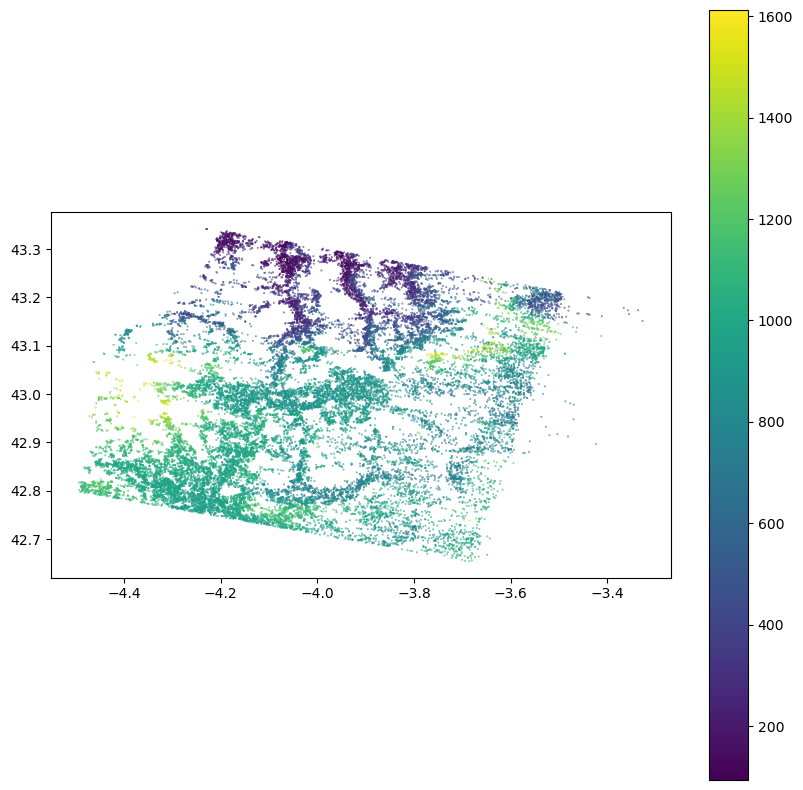

In [15]:
from matplotlib.colors import ListedColormap

# Create a custom colormap to display the classes
custom_colors = ListedColormap([ 'navy', 'green', 'darkgreen', 'red', 'orange', 'blue', 'royalblue'])

# convert the classes from integer to categories
classes = {
    1: 'land',
    2: 'land_near_water',
    3: 'water_near_land',
    4: 'open_water',
    5: 'dark_water',
    6: 'low_coh_water_near_land',
    7: 'open_low_coh_water'
}

gdf['classes'] = gdf['classification'].map(classes).astype('category')

# apply Log to the coherent_power to better visualization
gdf['log_power'] = np.log(gdf['coherent_power'])

gdf.sample(30000).plot(markersize=0.1, 
                        column='height', 
                        figsize=(10, 10), 
                        legend=True
                        )

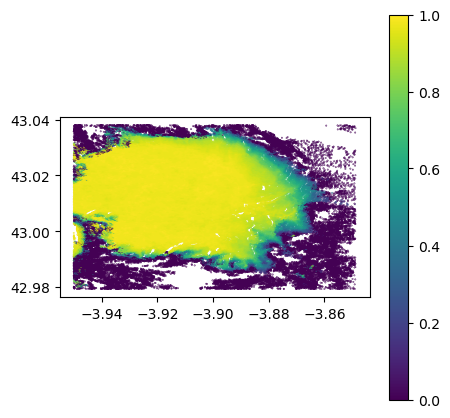

In [60]:
from shapely.geometry import box

# define a new area of interest
aoi2 = box(-3.8488500701464545,42.979179792697806, -3.950110649525726, 43.03812150577278)

# Get the points within this area of interest
gdf2 = gdf[gdf.geometry.within(aoi2)]

# Plot the new area of interest
ax1 = gdf2.plot(markersize=0.1, column='prior_water_prob', figsize=(5, 5), legend=True)

In [34]:
%pip install pystac_client stackstac planetary_computer --quiet --no-cache-dir

Note: you may need to restart the kernel to use updated packages.


In [39]:
import stackstac
import pystac_client
import planetary_computer as pc
import matplotlib.pyplot as plt

# Open the Planetary Computer Catalog
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,
)

# Specify a time window near our SWOT date
time_of_interest = "2023-11-03/2023-11-07"

# Search for Sentinel 2 items
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=aoi2.bounds,
    datetime=time_of_interest,
)
items = search.item_collection()

# Use stackstac to grab just the RGB bands within our AOI 
cube = stackstac.stack(
    items=items,
    bounds_latlon=aoi2.bounds,
    assets=['B04', 'B03', 'B02'],
    epsg=4326
)

# Copy cube into memory and rescale the bands
cube = (cube*1e-4).compute()
print(cube.squeeze().shape)

/opt/conda/envs/geo/lib/python3.11/site-packages/stackstac/prepare.py:408: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  times = pd.to_datetime(


(3, 646, 810)


/opt/conda/envs/geo/lib/python3.11/site-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)
/opt/conda/envs/geo/lib/python3.11/site-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


(-3.950110649525726, -3.8488500701464545)

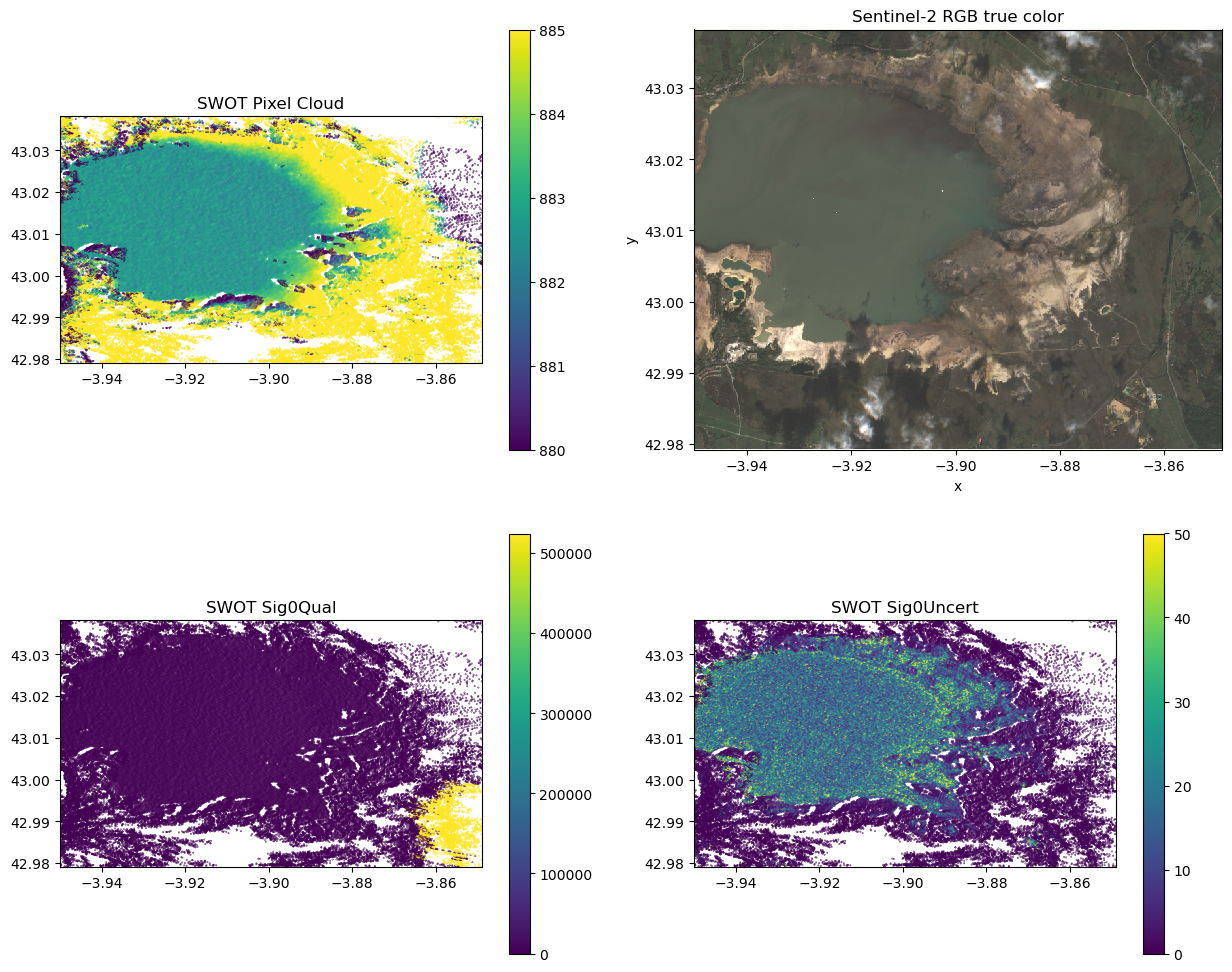

In [58]:
# Create a matplotlib figure 
figsize = (15, 12)
_, axs = plt.subplots(2, 2, figsize=figsize)

# get the bounds coordinates
xmin, ymin, xmax, ymax = aoi2.bounds

# plot SWOT points
gdf2.plot(ax=axs[0][0], markersize=0.1, column='height', legend=True, vmin = 880, vmax = 885)
axs[0][0].set_title('SWOT Pixel Cloud')

# make sure the viewport is showing exactly our AOI
axs[0][0].set_ylim([ymin, ymax])
axs[0][0].set_xlim([xmin, xmax])

# Plot the Sentinel 2
cube.squeeze().plot.imshow(rgb='band', vmin=0, vmax=0.5, ax=axs[0][1])
axs[0][1].set_title('Sentinel-2 RGB true color')

# Plot 3
gdf2.plot(ax=axs[1][0], markersize=0.1, column='sig0_qual', legend=True)
axs[1][0].set_title('SWOT Sig0Qual')

# make sure the viewport is showing exactly our AOI
axs[1][0].set_ylim([ymin, ymax])
axs[1][0].set_xlim([xmin, xmax])

# Plot 3
gdf2.plot(ax=axs[1][1], markersize=0.1, column='sig0_uncert', legend=True, vmin = 0, vmax = 50)
axs[1][1].set_title('SWOT Sig0Uncert')

# make sure the viewport is showing exactly our AOI
axs[1][1].set_ylim([ymin, ymax])
axs[1][1].set_xlim([xmin, xmax])

In [ ]:
# Create a matplotlib figure 
figsize = (15, 15)
_, axs = plt.subplots(2, 2, figsize=figsize)

# get the bounds coordinates
xmin, ymin, xmax, ymax = aoi2.bounds

# plot SWOT points
gdf2.plot(ax=axs[0][0], markersize=0.1, column='water_frac_uncert', legend=True)
axs[0][0].set_title('water_frac_uncert')

# make sure the viewport is showing exactly our AOI
axs[0][0].set_ylim([ymin, ymax])
axs[0][0].set_xlim([xmin, xmax])

# Plot tvar2
gdf2.plot(ax=axs[0][1], markersize=0.1, column='phase_noise_std', legend=True)
axs[0][1].set_title('phase_noise_std')

# make sure the viewport is showing exactly our AOI
axs[0][1].set_ylim([ymin, ymax])
axs[0][1].set_xlim([xmin, xmax])

# Plot 3
gdf2.plot(ax=axs[1][0], markersize=0.1, column='phase_unwrapping_region', legend=True)
axs[1][0].set_title('phase_unwrapping_region')

# make sure the viewport is showing exactly our AOI
axs[1][0].set_ylim([ymin, ymax])
axs[1][0].set_xlim([xmin, xmax])

# Plot 3
gdf2.plot(ax=axs[1][1], markersize=0.1, column='dheight_droll', legend=True)
axs[1][1].set_title('dheight_droll')

# make sure the viewport is showing exactly our AOI
axs[1][1].set_ylim([ymin, ymax])
axs[1][1].set_xlim([xmin, xmax])

#         'water_frac_uncert': ds_pixc.water_frac_uncert.values.astype('float64'),
#         'phase_noise_std': ds_pixc.phase_noise_std.values.astype('float32'),
#         'phase_unwrapping_region': ds_pixc.phase_unwrapping_region.values.astype('float32'),
#         'dheight_droll': ds_pixc.dheight_droll.values.astype('float32'),
#         'ancillary_surface_classification_flag': ds_pixc.ancillary_surface_classification_flag.values.astype('float32'),
#         'interferogram_qual': ds_pixc.interferogram_qual.values.astype('float32'),
#         'geolocation_qual': ds_pixc.geolocation_qual.values.astype('float32'),
        # 'dheight_dphase': ds_pixc.dheight_dphase.values.astype('float32'),
        # 'dheight_droll': ds_pixc.dheight_droll.values.astype('float32'),
        # 'power_plus_y': ds_pixc.power_plus_y.values.astype('float32'),
        # 'power_minus_y': ds_pixc.power_minus_y.values.astype('float32'),
        

In [62]:
# Create a matplotlib figure 
figsize = (15, 15)
_, axs = plt.subplots(2, 2, figsize=figsize)

# get the bounds coordinates
xmin, ymin, xmax, ymax = aoi2.bounds

# plot SWOT points
gdf2.plot(ax=axs[0][0], markersize=0.1, column='dheight_dphase', legend=True)
axs[0][0].set_title('dheight_dphase')

# make sure the viewport is showing exactly our AOI
axs[0][0].set_ylim([ymin, ymax])
axs[0][0].set_xlim([xmin, xmax])

# Plot tvar2
gdf2.plot(ax=axs[0][1], markersize=0.1, column='dheight_droll', legend=True)
axs[0][1].set_title('dheight_droll')

# make sure the viewport is showing exactly our AOI
axs[0][1].set_ylim([ymin, ymax])
axs[0][1].set_xlim([xmin, xmax])

# Plot 3
gdf2.plot(ax=axs[1][0], markersize=0.1, column='power_plus_y', vmax= 1.5, legend=True)
axs[1][0].set_title('power_plus_y')

# make sure the viewport is showing exactly our AOI
axs[1][0].set_ylim([ymin, ymax])
axs[1][0].set_xlim([xmin, xmax])

# Plot 3
gdf2.plot(ax=axs[1][1], markersize=0.1, column='power_minus_y', legend=True)
axs[1][1].set_title('power_minus_y')

# make sure the viewport is showing exactly our AOI
axs[1][1].set_ylim([ymin, ymax])
axs[1][1].set_xlim([xmin, xmax])

        # 'dheight_dphase': ds_pixc.dheight_dphase.values.astype('float32'),
        # 'dheight_droll': ds_pixc.dheight_droll.values.astype('float32'),
        # 'power_plus_y': ds_pixc.power_plus_y.values.astype('float32'),
        # 'power_minus_y': ds_pixc.power_minus_y.values.astype('float32'),

ValueError: minvalue must be less than or equal to maxvalue

ValueError: minvalue must be less than or equal to maxvalue

<Figure size 1500x1500 with 7 Axes>

Text(0.5, 1.0, 'Sentinel-2 RGB true color')

<Figure size 640x480 with 0 Axes>

/opt/conda/envs/geo/lib/python3.11/site-packages/stackstac/prepare.py:408: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  times = pd.to_datetime(
/opt/conda/envs/geo/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:188: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Text(0.5, 1.0, 'Simple Water Mask')

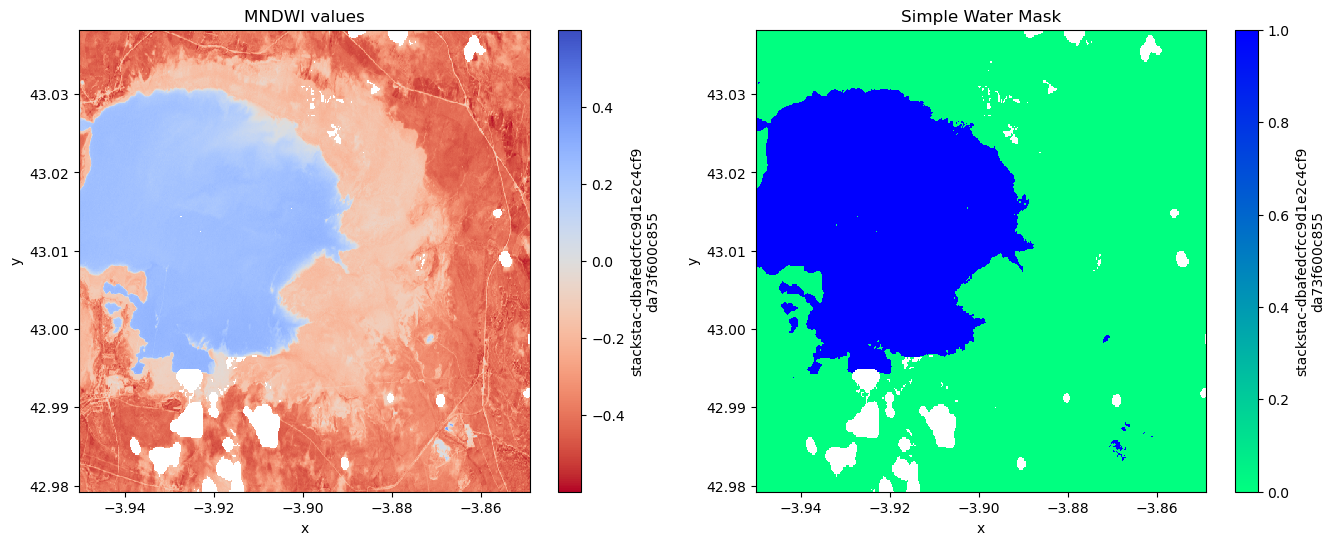

In [37]:
# Let's download the bands to compute the NDWI
# odified Normalized Difference Water Index
cube = stackstac.stack(
    items=items,
    bounds_latlon=aoi2.bounds,
    assets=['B03', 'B08', 'SCL'],
    epsg=4326
)

# Copy cube into memory and rescale the bands
cube = cube.compute()

# get the bands separately
nir = cube.sel(band='B08') * 1e-4
green = cube.sel(band='B03') * 1e-4
scl = cube.sel(band='SCL').astype('uint8')

# create the cloud mask by masking the classes:
# 3 - Cloud shadow
# 8 - Medium probability cloud 
# 9 - High probability cloud
cloud_mask = scl.isin([3, 8, 9])

# compute the ndwi and exclude masked pixels
mndwi = (green - nir) / (green + nir)
mndwi = mndwi.where(~cloud_mask)

# compute the water mask
water = mndwi > 0
water = water.where(~cloud_mask)

# Plot the resulting water mask
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

mndwi.plot(ax=axs[0], cmap='coolwarm_r',  add_colorbar=True)
axs[0].set_title('MNDWI values')
water.plot(ax=axs[1], cmap='winter_r', add_colorbar=True)
axs[1].set_title('Simple Water Mask')

Note: you may need to restart the kernel to use updated packages.


<Axes: >

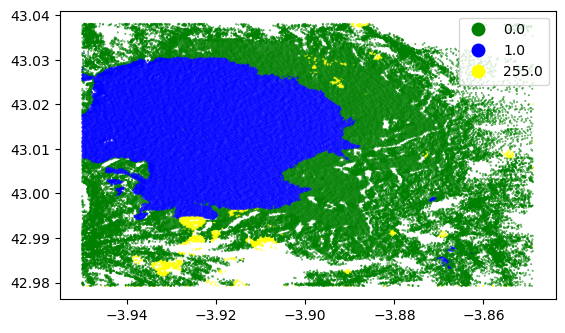

In [25]:

%pip install rioxarray --quiet --no-cache-dir

import tempfile
import rioxarray as xrio
import rasterio as rio
import numpy as np


# Create a temporary file path
temp_file_path = tempfile.NamedTemporaryFile(suffix='.tif').name

# prepare the water mask to be saved to the temp file
# we will set 255 as nodata
water = water.fillna(255)
water = water.rio.write_nodata(255).astype('uint8')

# Save the xarray to the temporary file
water.rio.to_raster(temp_file_path, compress='deflate')

# open the water mask in a rasterio dataset
ds = rio.open(temp_file_path)

# Grab the cords as tuples from the Pixel Cloud dataset
coords = [(x, y) for x, y in zip(gdf2.longitude, gdf2.latitude)]
# get the water mask values within the coords
pix_sampling = list(ds.sample(coords))
pixc_msk = list(map(lambda x: x.item(), pix_sampling))
assert len(pixc_msk) == len(gdf2)

# assign water mask values to the pixel cloud dataframe
gdf2.loc[gdf2.index, 'water_mask'] = pixc_msk
gdf2.loc[gdf2.index, 'water_mask_class'] = gdf2['water_mask'].astype('category')

# Plot the classified pixel cloud
gdf2.plot(markersize=0.1, column='water_mask_class', legend=True, cmap = ListedColormap([ 'green', 'blue', 'yellow']))



/opt/conda/envs/geo/lib/python3.11/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: >

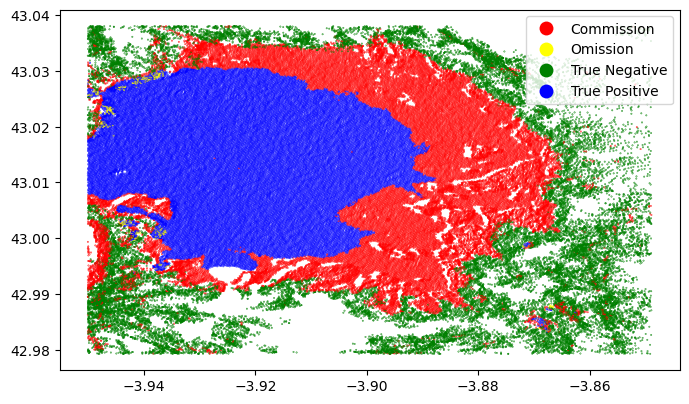

In [26]:
# Map the Swot class into a binary land/water classification
swot_class_map =  {
    'land': 0,
    'land_near_water': 0,
    'water_near_land': 1,
    'open_water': 1,
    'dark_water': 1,
    'low_coh_water_near_land': 1,
    'open_low_coh_water': 1
}

# now, we will map the swot mask to just true/false
gdf2.loc[gdf2.index, 'swot_class'] = gdf2['classes'].map(swot_class_map)

# Ignore the nodata (255) rows
gdf3 = gdf2[gdf2['water_mask_class'] != 255]

# Initialize the 'status' column 
gdf3['status'] = ''

# Define commission and omission errors considering water_class is ground truth
commission_errors = (gdf3['swot_class'] == 1) & (gdf3['water_mask_class'] == 0)
omission_errors = (gdf3['swot_class'] == 0) & (gdf3['water_mask_class'] == 1)

# Define true positives and true negatives
true_positives = (gdf3['swot_class'] == 1) & (gdf3['water_mask_class'] == 1)
true_negatives = (gdf3['swot_class'] == 0) & (gdf3['water_mask_class'] == 0)

# Assign status for each type of prediction
gdf3.loc[commission_errors, 'status'] = 'Commission'
gdf3.loc[omission_errors, 'status'] = 'Omission'
gdf3.loc[true_positives, 'status'] = 'True Positive'
gdf3.loc[true_negatives, 'status'] = 'True Negative'

# plot the map
gdf3.plot(markersize=0.1, column='status', legend=True, 
          cmap = ListedColormap([ 'red', 'yellow', 'green', 'blue']), figsize=(8, 8))